# Predicting Diabetes — Pima Indians dataset

This is my second ML project (the first one was wine quality). The dataset is from Kaggle: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database — it has medical measurements (glucose, blood pressure, BMI, age etc.) for 768 women, and the goal is to predict whether a patient has diabetes. So it's a binary classification problem. The plan is to try a few different models and see which one does best.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


768 patients and 9 columns. Outcome is the target (1 = diabetes, 0 = no diabetes), the other 8 are the features. Let's check how balanced the classes are.

In [3]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

So 500 vs 268 — not balanced. Important: if a model just always predicted "no diabetes" it would already get 500/768 = 65% accuracy. So 65% is the number to beat.

In [ ]:
df.isnull().sum()  

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


The minimum for Glucose, BloodPressure, SkinThickness, Insulin and BMI is 0. You can't have a blood pressure or a BMI of 0, so these are actually missing values filled with zeros.

I'll replace the zeros in those columns with the median.

In [ ]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print((df[zero_cols] == 0).sum())

for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median()) 

print()
print((df[zero_cols] == 0).sum()) 

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Insulin had 374 zeros and SkinThickness 227, that's a lot of replaced values.

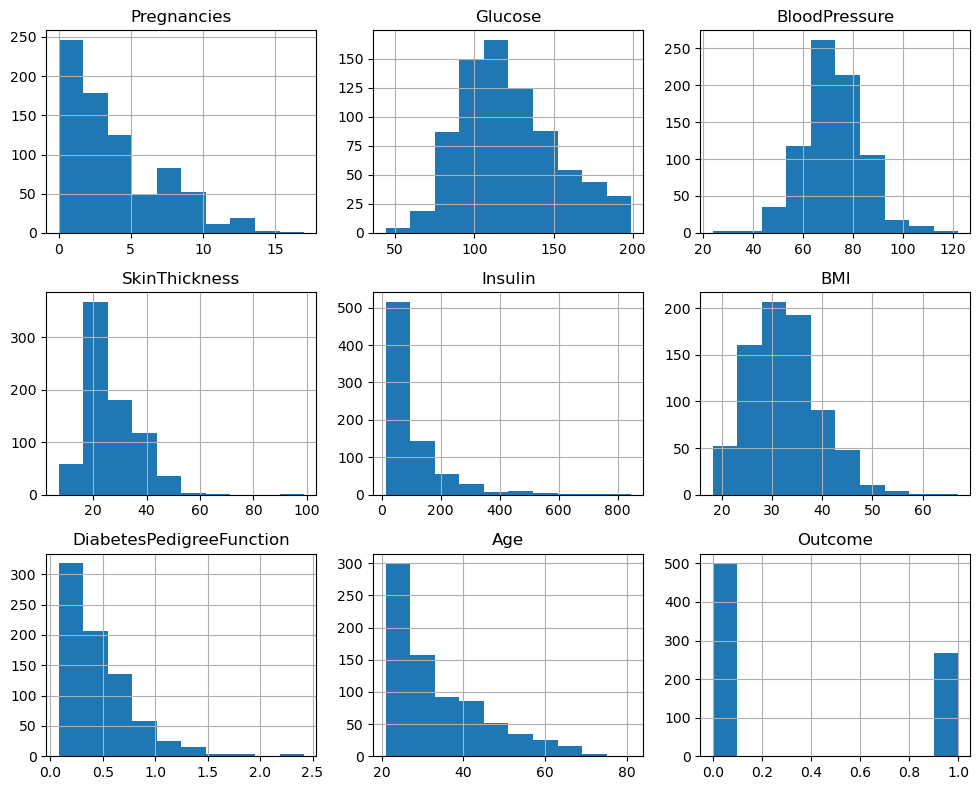

In [7]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [ ]:
# X = the medical features, y = what we want to predict
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


## Model 1: KNN

In [ ]:
knn = KNeighborsClassifier() 
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))

Accuracy: 0.6558441558441559
F1: 0.5619834710743802


65.6% accuracy — basically the same as always guessing "no diabetes". That makes sense though: KNN works on distances, and my features have completely different scales (Insulin goes up to ~850 while DiabetesPedigreeFunction never gets above 2.5).


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, knn_pred)
f1_knn = f1_score(y_test, knn_pred)
print("Accuracy:", acc_knn)
print("F1:", f1_knn)

Accuracy: 0.7532467532467533
F1: 0.6545454545454545


Much better — went from 65.6% to 75.3% just from scaling.


In [ ]:

for k in [3, 5, 7, 9, 11, 13]:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    p = m.predict(X_test_scaled)
    print(k, round(accuracy_score(y_test, p), 3))

3 0.727
5 0.753
7 0.747
9 0.734
11 0.721
13 0.753


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  
rf_pred = rf.predict(X_test)
acc_rf = accuracy_score(y_test, rf_pred)
f1_rf = f1_score(y_test, rf_pred)
print("Accuracy:", acc_rf)
print("F1:", f1_rf)

Accuracy: 0.7532467532467533
F1: 0.6607142857142857


## Model 3: Gradient Boosting

Also a tree ensemble, but the trees are built one after another and each new tree tries to fix the mistakes of the previous ones 

In [13]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
acc_gb = accuracy_score(y_test, gb_pred)
f1_gb = f1_score(y_test, gb_pred)
print("Accuracy:", acc_gb)
print("F1:", f1_gb)

Accuracy: 0.7337662337662337
F1: 0.6554621848739496


## Comparing the models

In [14]:
print(f"KNN (k=5, scaled):  accuracy={acc_knn:.3f}  f1={f1_knn:.3f}")
print(f"Random Forest:      accuracy={acc_rf:.3f}  f1={f1_rf:.3f}")
print(f"Gradient Boosting:  accuracy={acc_gb:.3f}  f1={f1_gb:.3f}")

KNN (k=5, scaled):  accuracy=0.753  f1=0.655
Random Forest:      accuracy=0.753  f1=0.661
Gradient Boosting:  accuracy=0.734  f1=0.655


Random Forest and KNN are tied on accuracy (75.3%) but RF has a slightly better F1, so I'd call Random Forest the winner. Gradient Boosting had the lowest accuracy of the three, which surprised me a bit because boosting usually wins on Kaggle — but I used the default settings, it probably needs tuning.

Honestly the differences are small. The test set is only 154 patients, so 2-3 predictions flipping already changes accuracy by ~2%. With a single train/test split I wouldn't trust this ranking too much — cross validation would give a more reliable comparison, that's for a future version.

Let's look at WHERE the random forest goes wrong:

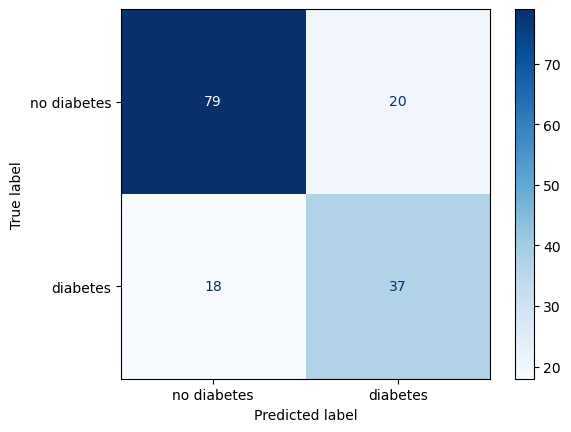

In [15]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no diabetes', 'diabetes'])
disp.plot(cmap='Blues')
plt.show()

It's good at spotting healthy patients (79 out of 99 correct) but it misses 18 of the 55 actual diabetes cases — about a third. For a medical problem that's the bad kind of error (telling a sick person they're fine). I think it's because there are way fewer positive examples to learn from. Something to fix later, maybe with class_weight='balanced' or oversampling.

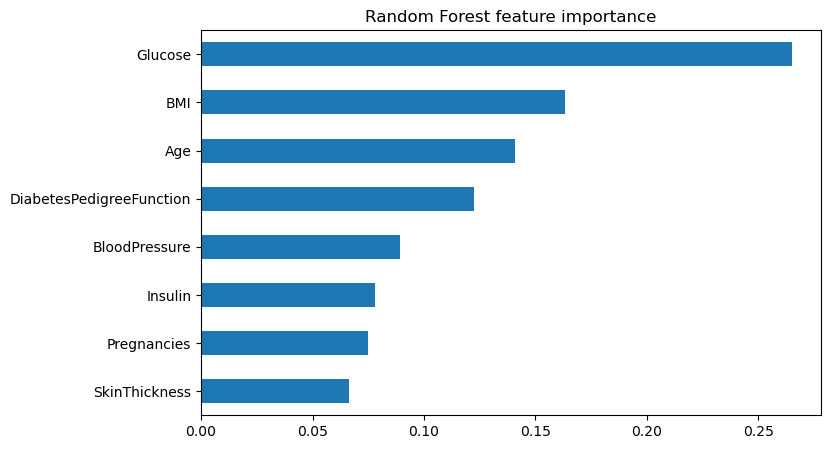

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', figsize=(8, 5))
plt.title('Random Forest feature importance')
plt.show()

Glucose is by far the most important feature, which makes sense — high blood sugar is basically what diabetes is. BMI and Age come next.

## Conclusion

- Best model: Random Forest with ~75% accuracy and 0.66 F1 (the baseline was 65%)
- Biggest lessons: missing values can hide as zeros, and scaling matters a LOT for KNN (+10% accuracy) but not for trees
- What I'd try next: cross validation instead of a single split, GridSearchCV for the hyperparameters, doing something about the class imbalance, maybe XGBoost